# Exercise 6: Decision Trees

```{admonition} Run or download this notebook
:class: how-to-use

This page is fully readable as it is, and the interactive activities work
here in the browser. To **run or change the Python code**, use the portable
version of the notebook:

- **[Open the portable notebook in Colab](https://colab.research.google.com/github/yoavmp/ml-neuro-tutorials/blob/main/book/downloads/chapter_06/exercise_06_portable.ipynb)**
- **[View or download the portable `.ipynb`](https://raw.githubusercontent.com/yoavmp/ml-neuro-tutorials/main/book/downloads/chapter_06/exercise_06_portable.ipynb)**
  for VS Code or Jupyter

The portable notebook keeps every Python analysis cell and swaps each
embedded activity for a link back to this page.
```

## What this notebook covers

This is Exercise 6 of *Machine Learning for Neuroscience*. Exercise 6
introduces regression trees and the greedy algorithm used to build them. We
will then compare a single tree with bagging and Random Forest models.

In this notebook you will:

1. examine how a tree divides feature space;
2. choose a split using MSE;
3. see how tree complexity affects overfitting;
4. compare a single tree, bagging, and Random Forest.

**Prerequisites:** Exercises 2, 4, and 5 (predicting age from cortical
thickness, training/validation splitting, and regularization).

## 1. One Regression Tree

We return to the same task as Exercises 2, 4, and 5: predicting a
participant's age at scan from cortical-thickness measurements. Earlier
exercises fit a linear model to every predictor at once. A regression tree
takes a different approach: it repeatedly divides the participants into
groups using simple yes/no questions about one feature at a time, and
predicts the average age within each final group.

A tree is built from three kinds of pieces:

- a **node** is one point in the tree, holding a subset of the training
  participants;
- each internal node tests **one feature against one threshold** (for
  example, "is this region's average cortical thickness at most 1.8mm?")
  and sends each participant left or right depending on the answer;
- a **leaf** is a node that is not split any further; it predicts the mean
  target value among the training participants who reach it.

Unlike the linear and regularized models in Exercises 2, 4, and 5, decision
trees do **not** require feature scaling: a tree only compares a feature's
own values against a threshold, so the unit or scale of that feature never
changes which threshold is chosen.

In [1]:
# Data loading. In the published book this cell is collapsed; it is plain,
# runnable Python -- one public CSV pinned to an immutable commit. This is
# the exact same ABIDE-II table Exercises 2, 4, and 5 use, with age as a
# native column.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

PIN = "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b"
BASE = f"https://raw.githubusercontent.com/neurohackademy/nh2020-curriculum/{PIN}/tu-machine-learning-yarkoni/data"

model_df = pd.read_csv(f"{BASE}/abide2.tsv", sep="\t")
model_df = model_df.loc[:, [c for c in model_df.columns if not str(c).startswith("Unnamed")]]

BRAIN_COLS = [c for c in model_df.columns if c.startswith("fs")]
print(f"data table: {model_df.shape[0]} participants x {model_df.shape[1]} columns")

data table: 1004 participants x 1446 columns


In [2]:
# The same fixed 360 cortical-thickness predictors and fixed, stratified
# train/test split used throughout Exercises 2, 4, and 5. A further split of
# the training partition (identical to Exercises 4 and 5's own fitting/
# validation split) is used for sections 1 and 3 below; the test set stays
# untouched throughout this notebook.
FEATURES = [c for c in BRAIN_COLS if c.startswith("fsCT_")]
assert all(c.startswith("fsCT_") for c in FEATURES)
assert "age" not in FEATURES

has_age = model_df["age"].notna()
X = model_df.loc[has_age, FEATURES].to_numpy(float)
y = model_df.loc[has_age, "age"].to_numpy(float)
groups = model_df.loc[has_age, "group"].to_numpy()

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.25, random_state=42, stratify=groups
)
X_fit, X_val, y_fit, y_val, groups_fit, groups_val = train_test_split(
    X_train, y_train, groups_train, test_size=0.25, random_state=7, stratify=groups_train
)
print(f"{len(FEATURES)} predictors")
print(f"n_fit = {len(y_fit)}   n_val = {len(y_val)}   n_test = {len(y_test)} (test set untouched in this notebook)")

360 predictors
n_fit = 564   n_val = 189   n_test = 251 (test set untouched in this notebook)


In [3]:
# Two predefined predictors from the compact "sensorimotor core" bundle
# already used elsewhere in this course: the two primary somatosensory/motor
# cortical-thickness regions with the strongest training-partition
# correlation with age within that small, predefined bundle (not a search
# across all 360 predictors).
TREE_FEATURES = ["fsCT_L_3a_ROI", "fsCT_R_2_ROI"]
idx = [FEATURES.index(f) for f in TREE_FEATURES]
Xp_fit, Xp_val = X_fit[:, idx], X_val[:, idx]

tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=20, random_state=42)
tree.fit(Xp_fit, y_fit)

pred_val = tree.predict(Xp_val)
print(f"leaves = {tree.get_n_leaves()}   depth = {tree.get_depth()}")
print(f"validation MSE = {mean_squared_error(y_val, pred_val):.1f}   "
      f"validation R2 = {r2_score(y_val, pred_val):.3f}")

leaves = 8   depth = 3
validation MSE = 46.0   validation R2 = 0.361


### Tree diagram

Each box below shows the feature and threshold tested at that node (for a
leaf, its predicted age instead), how many training participants reach it,
and the mean age among them.

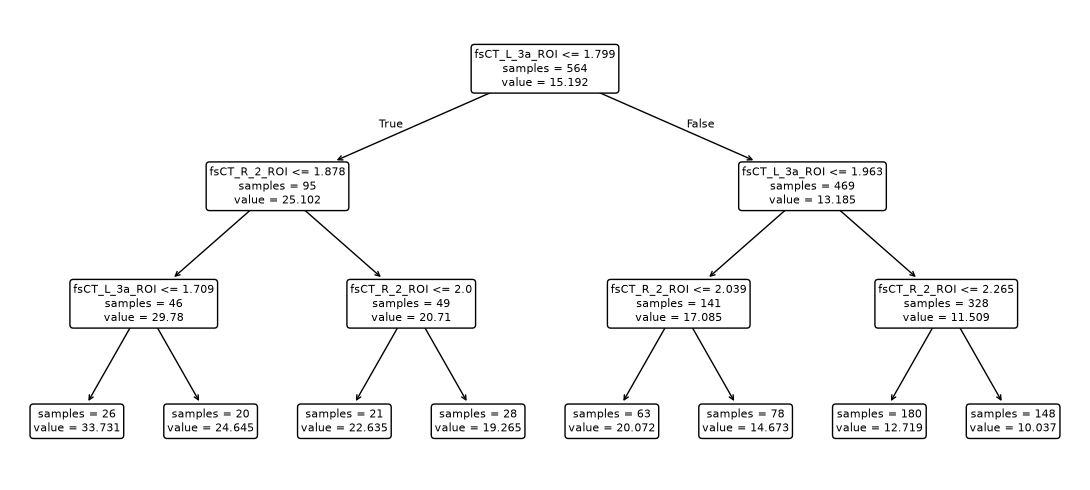

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_tree(
    tree, feature_names=TREE_FEATURES, filled=False, impurity=False,
    rounded=True, fontsize=8, ax=ax,
)
plt.tight_layout()
plt.show()

### Two-dimensional partition plot

Both predictors can be plotted directly, since there are only two: one on
each axis. The background color shows what the tree would predict for any
point in this space; the dots are the actual training participants, colored
by their observed age.

> A split on the horizontal-axis feature produces a vertical boundary. A
> split on the vertical-axis feature produces a horizontal boundary.

Standard regression-tree splits are **axis-aligned**: every individual
boundary is a straight vertical or horizontal line, never diagonal or
curved. Several rectangular regions together can still approximate a
nonlinear relationship, one step at a time. Because every point inside one
rectangular region receives the same prediction, regression-tree predictions
are **piecewise constant** -- flat within each region, with a jump at every
boundary.

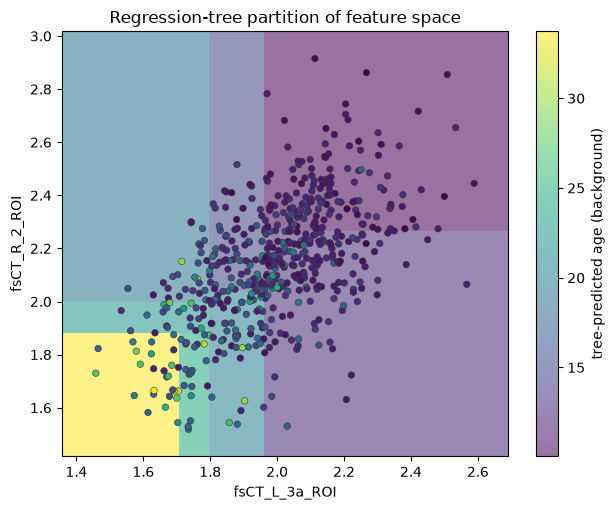

In [5]:
x1_grid = np.linspace(Xp_fit[:, 0].min() - 0.1, Xp_fit[:, 0].max() + 0.1, 300)
x2_grid = np.linspace(Xp_fit[:, 1].min() - 0.1, Xp_fit[:, 1].max() + 0.1, 300)
xx1, xx2 = np.meshgrid(x1_grid, x2_grid)
mesh_pred = tree.predict(np.column_stack([xx1.ravel(), xx2.ravel()])).reshape(xx1.shape)

fig, ax = plt.subplots(figsize=(6.4, 5.2))
mesh = ax.pcolormesh(xx1, xx2, mesh_pred, shading="auto", cmap="viridis", alpha=0.55)
ax.scatter(Xp_fit[:, 0], Xp_fit[:, 1], c=y_fit, cmap="viridis", edgecolor="0.2", linewidth=0.4, s=22)
plt.colorbar(mesh, ax=ax, label="tree-predicted age (background)")
ax.set_xlabel(TREE_FEATURES[0])
ax.set_ylabel(TREE_FEATURES[1])
ax.set_title("Regression-tree partition of feature space")
plt.tight_layout()
plt.show()

```{admonition} Think first
:class: think-first
- Why is every boundary in the plot above parallel to one axis?
- Why does every rectangular region carry exactly one prediction?
- Can several axis-aligned splits together approximate a curved
  relationship?
- What may happen to a leaf's prediction when very few participants reach
  it?
```

## 2. Build a Tree Greedily

How does a tree decide which feature and threshold to split on? Consider one
node containing $n$ training observations with target values
$y_1, \dots, y_n$. A leaf at this node would predict their mean:

$$
\hat{y}_{\mathrm{leaf}} = \frac{1}{n}\sum_{i=1}^{n} y_i
$$

and its mean squared error is

$$
\operatorname{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_{\mathrm{leaf}})^2
$$

For a proposed split into a left group of $n_L$ observations and a right
group of $n_R$ observations ($n_L + n_R = n$), each with its own leaf mean
and its own MSE, the split's overall error is the size-weighted average of
the two children's MSE:

$$
\operatorname{MSE}_{\mathrm{split}} = \frac{n_L}{n}\operatorname{MSE}_L + \frac{n_R}{n}\operatorname{MSE}_R
$$

**The tree chooses the feature and threshold that produce the largest
reduction in MSE at the current node** -- the drop from the parent's MSE to
$\operatorname{MSE}_{\mathrm{split}}$.

This procedure is called **greedy**: the algorithm chooses the best split
available right now, at this one node. It does not look several splits
ahead, and it never reconsiders a split it has already made.

### Interactive activity: Build a Tree Greedily

The activity below uses a small, **synthetic** dataset -- 16 points on two
predictors, $X_1$ and $X_2$, built to have an understandable split
structure rather than drawn from real participants. It walks you through
three nodes: the root, then one of its children, then the other. At each
node, choose a feature and browse the candidate thresholds; the score card
updates the weighted split MSE and MSE reduction as you go. Lock your
choice, then reveal the greedy optimum for that node and compare. The
activity itself always continues with the true greedy-optimal split, not
your own proposal, so that later nodes reflect the actual tree the algorithm
would build.

<iframe
  title="Interactive greedy-splitting activity for a small synthetic regression tree"
  src="../../_static/widgets/app/index.html?config=../configs/tree_greedy_split.json"
  loading="lazy"
  width="100%"
  height="1500"
  class="ml-activity"
  style="width: 100%;"
></iframe>

In [6]:
# Optional: a compact Python reproduction of how the activity's candidate
# thresholds and split MSE are calculated, using its own synthetic dataset.
greedy_points = [
    (1.0, 1.0, 7.0), (2.0, 2.0, 7.7), (3.0, 3.0, 8.3), (4.0, 4.0, 9.0),
    (1.0, 7.0, 17.0), (2.0, 8.0, 17.7), (3.0, 9.0, 18.3), (4.0, 10.0, 19.0),
    (7.0, 1.0, 25.0), (8.0, 2.0, 25.7), (9.0, 3.0, 26.3), (10.0, 4.0, 27.0),
    (7.0, 7.0, 39.0), (8.0, 8.0, 39.7), (9.0, 9.0, 40.3), (10.0, 10.0, 41.0),
]
ys = np.array([p[2] for p in greedy_points])


def weighted_split_mse(feature_index, threshold, points):
    left = np.array([p[2] for p in points if p[feature_index] <= threshold])
    right = np.array([p[2] for p in points if p[feature_index] > threshold])
    n = len(points)
    return (len(left) / n) * left.var() + (len(right) / n) * right.var()


x1_values = sorted({p[0] for p in greedy_points})
candidate_thresholds = [(a + b) / 2 for a, b in zip(x1_values, x1_values[1:])]
parent_mse = ys.var()
split_mses = [weighted_split_mse(0, t, greedy_points) for t in candidate_thresholds]
best_i = int(np.argmin(split_mses))

print(f"root parent MSE = {parent_mse:.2f}")
for t, m in zip(candidate_thresholds, split_mses):
    print(f"  X1 <= {t:4.1f}   weighted split MSE = {m:6.2f}   reduction = {parent_mse - m:6.2f}")
print(f"best X1 threshold = {candidate_thresholds[best_i]:.1f}  "
      f"(reduction = {parent_mse - split_mses[best_i]:.2f})")

root parent MSE = 137.55
  X1 <=  1.5   weighted split MSE = 120.26   reduction =  17.29
  X1 <=  2.5   weighted split MSE =  99.74   reduction =  37.81
  X1 <=  3.5   weighted split MSE =  73.48   reduction =  64.07
  X1 <=  5.5   weighted split MSE =  37.55   reduction = 100.00
  X1 <=  7.5   weighted split MSE =  73.48   reduction =  64.07
  X1 <=  8.5   weighted split MSE =  99.74   reduction =  37.81
  X1 <=  9.5   weighted split MSE = 120.26   reduction =  17.29
best X1 threshold = 5.5  (reduction = 100.00)


```{admonition} Think again, after using the activity
:class: think-first
- Which mattered more for the best split: equal group sizes, or similar
  target values within each child?
- Did a visually reasonable-looking split ever have a worse MSE than you
  expected?
- The algorithm chose the best split available at each node. Did it know
  whether that split would still look best two levels later?
- Could the locally best split at the root ever lead to a less good
  complete tree than a different root split would have?
- Why are the candidate thresholds placed between observed values, rather
  than on top of them?
```

## 3. How Large Should the Tree Be?

A tree can keep splitting until every leaf contains a single participant,
fitting the training data almost perfectly -- and generalizing poorly. Three
settings control how large a tree is allowed to grow:

| Hyperparameter | Effect |
| --- | --- |
| `max_depth` | Limits how many successive splits any path from the root can have |
| `min_samples_leaf` | Prevents a leaf from being created with very few participants |
| `ccp_alpha` | Prunes back branches that add only limited improvement, after growing |

The figure below fits a tree at each depth from 1 to 10 (the same fitting
and validation partitions as Section 1), and tracks training and validation
MSE.

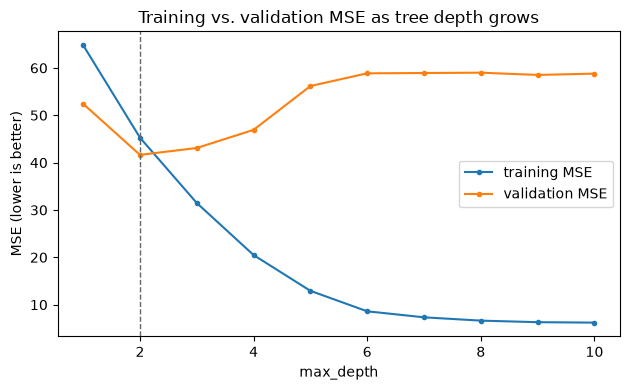

depth= 1  leaves=  2  train MSE= 64.80  val MSE= 52.42
depth= 2  leaves=  4  train MSE= 45.28  val MSE= 41.64  <- lowest validation MSE
depth= 3  leaves=  8  train MSE= 31.47  val MSE= 43.09
depth= 4  leaves= 15  train MSE= 20.48  val MSE= 46.93
depth= 5  leaves= 26  train MSE= 12.92  val MSE= 56.18
depth= 6  leaves= 41  train MSE=  8.60  val MSE= 58.87
depth= 7  leaves= 54  train MSE=  7.33  val MSE= 58.93
depth= 8  leaves= 66  train MSE=  6.63  val MSE= 59.00
depth= 9  leaves= 78  train MSE=  6.30  val MSE= 58.52
depth=10  leaves= 85  train MSE=  6.21  val MSE= 58.80


In [7]:
depths = list(range(1, 11))
train_mse, val_mse, n_leaves = [], [], []
for d in depths:
    t = DecisionTreeRegressor(max_depth=d, min_samples_leaf=5, random_state=42)
    t.fit(X_fit, y_fit)
    train_mse.append(mean_squared_error(y_fit, t.predict(X_fit)))
    val_mse.append(mean_squared_error(y_val, t.predict(X_val)))
    n_leaves.append(t.get_n_leaves())

best_depth = depths[int(np.argmin(val_mse))]

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(depths, train_mse, marker=".", label="training MSE")
ax.plot(depths, val_mse, marker=".", label="validation MSE")
ax.axvline(best_depth, color="0.4", ls="--", lw=1)
ax.set_xlabel("max_depth")
ax.set_ylabel("MSE (lower is better)")
ax.set_title("Training vs. validation MSE as tree depth grows")
ax.legend()
plt.tight_layout()
plt.show()

for d, tr, va, nl in zip(depths, train_mse, val_mse, n_leaves):
    marker = "  <- lowest validation MSE" if d == best_depth else ""
    print(f"depth={d:2d}  leaves={nl:3d}  train MSE={tr:6.2f}  val MSE={va:6.2f}{marker}")

Training MSE keeps falling as the tree grows deeper -- a sufficiently deep
tree can fit the training participants almost exactly. Validation MSE falls
at first, reaches a minimum at a shallow depth, and then rises again: past
that point, the tree is fitting patterns specific to these particular
training participants rather than the underlying relationship. A deeper tree
is more sensitive to exactly which participants happened to be in the
training set, because each additional split is chosen from an
ever-smaller, more idiosyncratic subgroup.

```{admonition} Think first
:class: think-first
- Which depth has the lowest training MSE?
- Does validation MSE keep improving as depth grows, or does it turn back
  up?
- Why is a deep tree more sensitive to exactly which participants are in
  the training set?
- Which depth would you select if you could not look at test data at all?
```

## 4. From One Tree to an Ensemble

### A single tree can be sensitive to the training sample

Fitting the same tree settings to several different, overlapping subsamples
of the same training pool can select a different feature or threshold at
the root -- not because anything about the algorithm changed, but because a
different set of participants was available to compare candidate splits
against.

In [8]:
# Three deterministic subsamples of the fitting partition (70% each, drawn
# without replacement) -- not merely different random_state values on
# identical data.
pool_size = len(y_fit)
for seed in [0, 1, 2]:
    rng = np.random.RandomState(seed)
    sample_idx = rng.choice(pool_size, size=int(round(0.7 * pool_size)), replace=False)
    t = DecisionTreeRegressor(max_depth=6, min_samples_leaf=5, random_state=42)
    t.fit(X_fit[sample_idx], y_fit[sample_idx])
    root_feature = FEATURES[t.tree_.feature[0]]
    root_threshold = t.tree_.threshold[0]
    print(f"training sample seed={seed}: root split on {root_feature} <= {root_threshold:.3f}")

training sample seed=0: root split on fsCT_R_V2_ROI <= 1.975
training sample seed=1: root split on fsCT_R_3a_ROI <= 1.596
training sample seed=2: root split on fsCT_R_V2_ROI <= 2.020


Two of the three samples above happen to choose the same root feature at a
different threshold; the third chooses a different feature entirely. This is
what "**sensitive**" or "**high variance**" means for a single tree: small
changes in *which participants are available to train on* can change early
splits and, from there, the rest of the tree. Refitting the identical tree
to identical data with a different `random_state` would **not**, by itself,
demonstrate this -- a `DecisionTreeRegressor` fit is deterministic given its
training data; what varies above is the training sample itself.

### Bagging

**Bagging** (bootstrap aggregating) addresses this sensitivity directly:

1. draw many bootstrap samples (random samples of the same size, drawn
   *with* replacement) from the training data;
2. fit one tree to each bootstrap sample;
3. predict with every tree;
4. average their predictions.

For regression, with $B$ trees:

$$
\hat{y}_{\mathrm{bagging}} = \frac{1}{B}\sum_{b=1}^{B} \hat{y}^{(b)}
$$

Averaging many trees, each somewhat different because each saw a different
bootstrap sample, mostly cancels out each individual tree's idiosyncrasies.
Bagging primarily reduces **variance** -- the sensitivity to the training
sample demonstrated above -- rather than changing what any one tree could
represent.

### Random Forest

> Random Forest combines bootstrap sampling with random feature subsets at
> each split.

Bagged trees can still end up fairly similar to one another when the same
few predictors dominate every bootstrap sample: if one feature is
consistently the best available split, most bootstrap trees will choose it
at the root regardless of which participants were resampled. Random Forest
adds a second source of randomness -- at every split, only a random subset
of the available features is even considered -- which makes the individual
trees less correlated with one another. Averaging less-correlated
predictions can improve on bagging, but it is not guaranteed to: this is an
empirical question, examined directly in Section 6.

| Model | Training samples | Features considered at a split | Prediction |
| --- | --- | --- | --- |
| Single tree | One training sample | All available features | One tree |
| Bagging | Bootstrap sample per tree | All available features | Average |
| Random Forest | Bootstrap sample per tree | Random feature subset | Average |

## 5. One Tree or Many?

The activity below compares a single regression tree, bagging, and a Random
Forest on the real age-prediction task, using the full 360-predictor recipe.
Each **training replicate** is a fixed proportion of the fitting partition,
drawn without replacement at a predefined seed -- a genuinely different
sample of participants, not just a different model seed on identical data.
Every model within a replicate trains on the identical subset and is scored
on the identical, fixed validation participants; bagging and Random Forest
additionally perform their own internal bootstrap sampling.

```{admonition} Think first
:class: think-first
- Which model should change the most across different training replicates?
- Will averaging many trees improve every individual prediction, or just
  the average?
- What should happen to validation MSE as more trees are added?
- Why might bagged trees remain fairly similar to one another?
- What additional randomness does Random Forest introduce beyond bagging?
```

<iframe
  title="Interactive comparison of a single tree, bagging, and Random Forest for predicting age from brain structure"
  src="../../_static/widgets/app/index.html?config=../configs/tree_ensemble_compare.json"
  loading="lazy"
  width="100%"
  height="1700"
  class="ml-activity"
  style="width: 100%;"
></iframe>

```{admonition} Think again, after using the activity
:class: think-first
- Which model showed the greatest variation across training replicates?
- Does adding trees mainly change average performance, its variability
  across replicates, or both?
- At roughly how many trees do results begin to stabilize?
- Did the Random Forest outperform bagging at every number of trees you
  tried?
- Why does averaging many trees reduce variance without making any
  individual tree shallower?
```

## 6. A Fair Model Comparison

As one further check, the three models are compared using identical
cross-validation folds over the full eligible cohort, with fixed,
predeclared complexity settings for every model -- no scaling (trees do not
need it), the same tree complexity for the single tree and for every tree
inside bagging and the Random Forest, the same number of trees for bagging
and Random Forest, and an explicit feature-subsampling size for the Random
Forest so its distinction from bagging is real rather than nominal. No
setting here was chosen by looking at the test set.

In [9]:
cv = KFold(n_splits=5, shuffle=True, random_state=100)
tree_settings = dict(max_depth=6, min_samples_leaf=5, random_state=42)
n_estimators = 50
random_forest_max_features = 19  # round(sqrt(360)); an alternative, p/3=120, was also audited

models = {
    "Single tree": DecisionTreeRegressor(**tree_settings),
    "Bagging": BaggingRegressor(DecisionTreeRegressor(**tree_settings), n_estimators=n_estimators, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=n_estimators, max_features=random_forest_max_features, **tree_settings
    ),
}

rows = []
for name, model in models.items():
    fold_mse = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1)
    fold_r2 = cross_val_score(model, X, y, cv=cv, scoring="r2", n_jobs=-1)
    rows.append({
        "Model": name,
        "Mean CV MSE": fold_mse.mean(),
        "MSE variability (sd)": fold_mse.std(),
        "Mean R2": fold_r2.mean(),
    })
pd.DataFrame(rows).set_index("Model").round(3)

,Mean CV MSE,MSE variability (sd),Mean R2
Model,,,
Single tree,57.443,3.755,0.308
Bagging,32.677,10.046,0.637
Random Forest,34.330,10.599,0.619


On this cohort and these settings, bagging and the Random Forest both
substantially outperform the single tree (roughly halving mean cross-
validation MSE), matching what Section 5's activity already showed. Between
the two ensembles, bagging scored marginally better than the Random Forest
here -- a reminder that ensemble advantages over a single tree are
consistent in this example, but a Random Forest outperforming bagging is
**not** guaranteed. Both are empirical outcomes, not properties either
method is entitled to by construction.

## 7. What Should We Remember?

- A regression tree splits feature space with axis-aligned boundaries: one
  feature and one threshold per split.
- Tree predictions are piecewise constant -- flat within each leaf's region.
- A deep tree can have very low training error and high variance: it
  becomes sensitive to exactly which participants were available to train
  on.
- Bagging fits many trees to bootstrap samples of the training data and
  averages their predictions.
- Random Forest does the same, but also restricts each split to a random
  subset of the available features.
- Averaging many trees reduces variance, whether or not the Random Forest's
  extra randomization improves on bagging in a given case.
- A tree-derived feature-importance score reflects how useful a feature was
  for prediction in this particular model; it does not, by itself,
  establish a feature's scientific or causal importance.

> Bagging and Random Forests build trees independently and average them. In
> the next exercise, boosting will build trees sequentially, with each new
> tree focusing on the errors left by earlier trees.

### Questions to take away

1. Why can a forest generalize better than any one of its individual deep
   trees?
2. What does Random Forest add on top of what bagging already does?
3. Why are the trees inside a Random Forest deliberately made different
   from one another?
4. When might a single, shallow tree still be the better choice?
5. Based on how bagging and Random Forest each build their trees
   independently and then average them, how do you expect boosting's
   sequential approach to differ?